# FRED Plot Examples

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy
from pathlib import Path
from datetime import datetime
from matplotlib import pyplot

sys.path.append('../')

from lib.utils import print_json_vertical
from utils import call_tool, children_of_categories, explore_categories, find_leaf_categories

from lib import config
from lib.plots import curve, PlotType

pyplot.style.use(config.glyfish_style)

MCP_URL = 'http://localhost:8080/sse'

## Monetary Data

cat_id = 24

In [2]:
args = {"category_id": 24}
result = await call_tool("fred.category_children", args)
children = result.structuredContent['result']['categories'] # type: ignore
print_json_vertical(children)

[
  {
    "id": 124,
    "name": "Monetary Base",
    "parent_id": 24
  },
  {
    "id": 123,
    "name": "Reserves",
    "parent_id": 24
  },
  {
    "id": 25,
    "name": "M1 and Components",
    "parent_id": 24
  },
  {
    "id": 29,
    "name": "M2 and Components",
    "parent_id": 24
  },
  {
    "id": 96,
    "name": "M2 Minus Small Time Deposits",
    "parent_id": 24
  },
  {
    "id": 28,
    "name": "M3 and Components",
    "parent_id": 24
  },
  {
    "id": 30,
    "name": "MZM",
    "parent_id": 24
  },
  {
    "id": 26,
    "name": "Memorandum Items",
    "parent_id": 24
  },
  {
    "id": 32242,
    "name": "Money Velocity",
    "notes": "Velocity is a ratio of nominal GDP to a measure of the money supply (M1 or M2).  It can be thought of as the rate of turnover in the money supply--that is, the number of times one dollar is used to purchase final goods and services included in GDP.",
    "parent_id": 24
  },
  {
    "id": 122,
    "name": "Borrowings",
    "parent_id": 24

In [3]:
await children_of_categories(children)

Category 124, Monetary Base has 0 children
Category 123, Reserves has 0 children
Category 25, M1 and Components has 0 children
Category 29, M2 and Components has 0 children
Category 96, M2 Minus Small Time Deposits has 0 children
Category 28, M3 and Components has 0 children
Category 30, MZM has 0 children
Category 26, Memorandum Items has 0 children
Category 32242, Money Velocity has 0 children
Category 122, Borrowings has 0 children
Category 32215, Factors Affecting Reserve Balances has 0 children
Category 32218, Securities, Loans, & Other Assets & Liabilities Held by Fed has 0 children


## Monetary Base, Series Information

In [4]:
tool_name = "fred.category_series"
args = {"category_id": 124}
result = await call_tool(tool_name, args)
series = result.structuredContent['result'] # type: ignore
print_json_vertical(series)

{
  "count": 27,
  "limit": 1000,
  "offset": 0,
  "order_by": "series_id",
  "realtime_end": "2026-01-04",
  "realtime_start": "2026-01-04",
  "seriess": [
    {
      "frequency": "Biweekly, Ending Wednesday",
      "frequency_short": "BW",
      "id": "ADJRAM",
      "last_updated": "2019-12-19T15:31:02-06:00",
      "notes": "Updates of this series will be ceased on December 19, 2019. There is no available alternative for this series.\nFor more details, see the FRED Announcement (https://news.research.stlouisfed.org/2019/12/discontinuance-of-st-louis-monetary-base-and-reserves-data/).",
      "observation_end": "2019-12-18",
      "observation_start": "1984-02-15",
      "popularity": 1,
      "seasonal_adjustment": "Not Seasonally Adjusted",
      "seasonal_adjustment_short": "NSA",
      "title": "Reserve Adjustment Magnitude (RAM) (DISCONTINUED)",
      "units": "Billions of Dollars",
      "units_short": "Bil. of $"
    },
    {
      "frequency": "Biweekly, Ending Wednesday",


### Monetary Base: Reserve Balances (BOGMBBM)

In [5]:
series_info = series['seriess'][11]
series_info

{'id': 'BOGMBBM',
 'title': 'Monetary Base: Reserve Balances',
 'observation_start': '1959-01-01',
 'observation_end': '2025-11-01',
 'frequency': 'Monthly',
 'frequency_short': 'M',
 'units': 'Billions of Dollars',
 'units_short': 'Bil. of $',
 'seasonal_adjustment': 'Not Seasonally Adjusted',
 'seasonal_adjustment_short': 'NSA',
 'last_updated': '2025-12-23T12:01:35-06:00',
 'popularity': 47,
 'notes': 'H.6 Technical Q&As (https://www.federalreserve.gov/releases/h6/h6_technical_qa.htm) posted on August 20, 2020.\n\nTotal balances maintained are balances that an institution holds in a reserve account directly at a Federal Reserve Bank.\n\nFor questions on the data, please contact the data source (https://www.federalreserve.gov/apps/ContactUs/feedback.aspx?refurl=/releases/h6/%). For questions on FRED functionality, please contact us here (https://fred.stlouisfed.org/contactus/).</p>'}

In [3]:
tool_name = "fred.series_observations"
args = {"series_id": "BOGMBBM", "limit": 10}
result = await call_tool(tool_name, args)
seriess = result.structuredContent['result'] # type: ignore
print_json_vertical(seriess)

{
  "count": 806,
  "limit": 10,
  "observations": [
    {
      "date": "1959-01-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "18.9"
    },
    {
      "date": "1959-02-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "18.6"
    },
    {
      "date": "1959-03-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "18.4"
    },
    {
      "date": "1959-04-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "18.7"
    },
    {
      "date": "1959-05-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "18.6"
    },
    {
      "date": "1959-06-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "18.5"
    },
    {
      "date": "1959-07-01",
      "realtime_end": "2026-03-29",
      "realtime_start": "2026-03-29",
      "value": "1

In [7]:
reserve_balances = numpy.array([float(obs["value"]) for obs in seriess['observations']])
date = numpy.array([datetime.strptime(obs["date"], "%Y-%m-%d") for obs in seriess['observations']])
title = series_info['title']
ylabel = series_info['units']
xlabel = "Date"

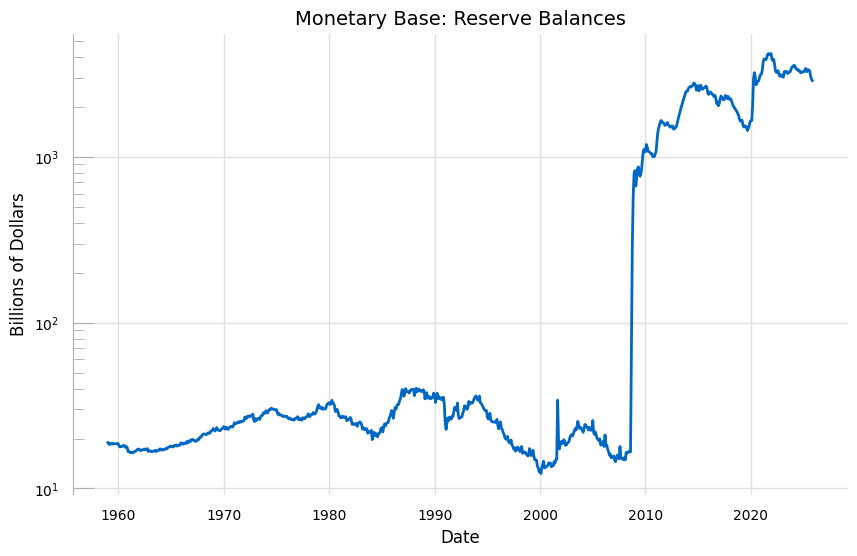

In [8]:
curve(reserve_balances, date, title=title, xlabel=xlabel, ylabel=ylabel, plot_axis_type=PlotType.YLOG)

## Multiple Calls for Observations

In [6]:
tool_name = "fred.series_observations"
args = {"series_id": "BOGMBBM", "limit": 5}
result = await call_tool(tool_name, args)
seriess = result.structuredContent['result'] # type: ignore
print_json_vertical(seriess)

{
  "count": 803,
  "limit": 5,
  "observations": [
    {
      "date": "1959-01-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.9"
    },
    {
      "date": "1959-02-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.6"
    },
    {
      "date": "1959-03-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.4"
    },
    {
      "date": "1959-04-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.7"
    },
    {
      "date": "1959-05-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.6"
    }
  ],
  "offset": 0,
  "order_by": "observation_date",
  "realtime_end": "2026-01-04",
  "realtime_start": "2026-01-04",
  "sort_order": "asc"
}


In [5]:
tool_name = "fred.series_observations"
args = {"series_id": "BOGMBBM", "limit": 5, "offset": 5}
result = await call_tool(tool_name, args)
seriess = result.structuredContent['result'] # type: ignore
print_json_vertical(seriess)

{
  "count": 803,
  "limit": 5,
  "observations": [
    {
      "date": "1959-06-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.5"
    },
    {
      "date": "1959-07-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.7"
    },
    {
      "date": "1959-08-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.6"
    },
    {
      "date": "1959-09-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.6"
    },
    {
      "date": "1959-10-01",
      "realtime_end": "2026-01-04",
      "realtime_start": "2026-01-04",
      "value": "18.6"
    }
  ],
  "offset": 5,
  "order_by": "observation_date",
  "realtime_end": "2026-01-04",
  "realtime_start": "2026-01-04",
  "sort_order": "asc"
}
